# COVID deaths analytics

## 1. Подключение к PostgreSQL

In [1]:
import os
from urllib.parse import quote_plus

import matplotlib.pyplot as plt
import pandas as pd
from sqlalchemy import create_engine

conn_params = {
    "host": os.getenv("POSTGRES_HOST", "postgres"),
    "port": os.getenv("POSTGRES_PORT", "5432"),
    "dbname": os.getenv("POSTGRES_DB", "airflow"),
    "user": os.getenv("POSTGRES_USER", "airflow"),
    "password": os.getenv("POSTGRES_PASSWORD", "airflow"),
}

db_url = (
    "postgresql+psycopg2://"
    f"{quote_plus(conn_params['user'])}:"
    f"{quote_plus(conn_params['password'])}@"
    f"{conn_params['host']}:{conn_params['port']}/"
    f"{conn_params['dbname']}"
)

engine = create_engine(db_url)
conn_params

{'host': 'postgres',
 'port': '5432',
 'dbname': 'airflow',
 'user': 'airflow',
 'password': 'airflow'}

In [2]:
def read_sql(query: str) -> pd.DataFrame:
    return pd.read_sql_query(query, engine)


## 2. Контроль наличия таблиц

In [3]:
read_sql("""
select table_schema, table_name
from information_schema.tables
where table_schema in ('raw', 'stage', 'mart')
order by table_schema, table_name;
""")

,table_schema,table_name
0,mart,covid_deaths_monthly
1,raw,covid_deaths_raw
2,stage,covid_deaths_daily


## 3. RAW слой

In [4]:
read_sql("""
select *
from raw.covid_deaths_raw
limit 5;
""")

,country_region,province_state,d_1_22_20,d_1_23_20,d_1_24_20,d_1_25_20,d_1_26_20,d_1_27_20,d_1_28_20,d_1_29_20,...,d_2_28_23,d_03_01_2023,d_03_02_2023,d_03_03_2023,d_03_04_2023,d_03_05_2023,d_03_06_2023,d_03_07_2023,d_03_08_2023,d_03_09_2023
0,Afghanistan,None,0,0,0,0,0,0,0,0,...,None,None,None,None,None,None,None,None,None,None
1,Albania,None,0,0,0,0,0,0,0,0,...,None,None,None,None,None,None,None,None,None,None
2,Algeria,None,0,0,0,0,0,0,0,0,...,None,None,None,None,None,None,None,None,None,None
3,Andorra,None,0,0,0,0,0,0,0,0,...,None,None,None,None,None,None,None,None,None,None
4,Angola,None,0,0,0,0,0,0,0,0,...,None,None,None,None,None,None,None,None,None,None


## 4. STAGE слой

In [5]:
read_sql("""
select country_region, province_state, report_date, cumulative_deaths, source_file
from stage.covid_deaths_daily
where country_region = 'Afghanistan'
order by report_date
limit 5;
""")

,country_region,province_state,report_date,cumulative_deaths,source_file
0,Afghanistan,None,2020-01-22,0,file:///usr/local/airflow/data/raw_2020.csv
1,Afghanistan,None,2020-01-23,0,file:///usr/local/airflow/data/raw_2020.csv
2,Afghanistan,None,2020-01-24,0,file:///usr/local/airflow/data/raw_2020.csv
3,Afghanistan,None,2020-01-25,0,file:///usr/local/airflow/data/raw_2020.csv
4,Afghanistan,None,2020-01-26,0,file:///usr/local/airflow/data/raw_2020.csv


## 5. MART витрина

In [6]:
mart_df = read_sql("""
select
    report_year,
    report_month,
    make_date(report_year::int, report_month::int, 1) as month_start_date,
    cumulative_deaths_month_end,
    monthly_deaths,
    processed_at
from mart.covid_deaths_monthly
order by report_year, report_month
""")
mart_df.head(5)

,report_year,report_month,month_start_date,cumulative_deaths_month_end,monthly_deaths,processed_at
0,2020,1,2020-01-01,214,214,2026-06-26 09:23:12.104948
1,2020,2,2020-02-01,2943,2729,2026-06-26 09:23:12.104948
2,2020,3,2020-03-01,47214,44271,2026-06-26 09:23:12.104948
3,2020,4,2020-04-01,253485,206271,2026-06-26 09:23:12.104948
4,2020,5,2020-05-01,406241,152756,2026-06-26 09:23:12.104948


## 6. Смерти по годам

In [7]:
yearly_df = read_sql("""
select
    report_year,
    sum(monthly_deaths)::bigint as yearly_deaths,
    max(cumulative_deaths_month_end) as cumulative_deaths_year_end,
    avg(monthly_deaths) as avg_monthly_deaths,
    max(monthly_deaths) as max_monthly_deaths
from mart.covid_deaths_monthly
group by report_year
order by report_year;
""")

yearly_df

,report_year,yearly_deaths,cumulative_deaths_year_end,avg_monthly_deaths,max_monthly_deaths
0,2020,1901760,1901760,158480.000000,356779
1,2021,3567197,5468957,297266.416667,421670
2,2022,1224356,6693313,102029.666667,278271
3,2023,188477,6881790,62825.666667,141983


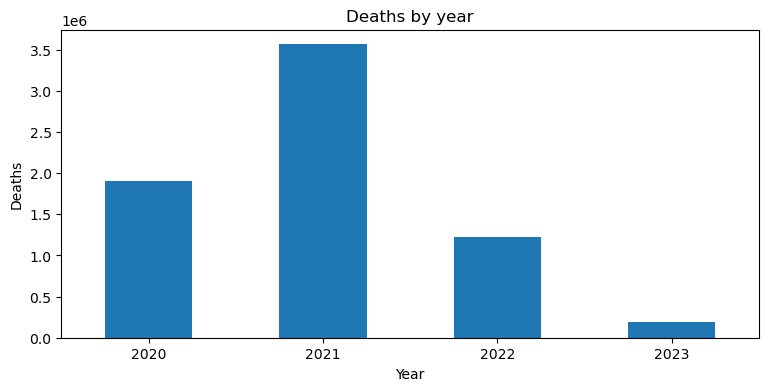

In [8]:
ax = yearly_df.plot(
    x="report_year",
    y="yearly_deaths",
    kind="bar",
    legend=False,
    figsize=(9, 4),
    title="Deaths by year",
)
ax.set_xlabel("Year")
ax.set_ylabel("Deaths")
plt.xticks(rotation=0)
plt.show()

## 7. Динамика по месяцам

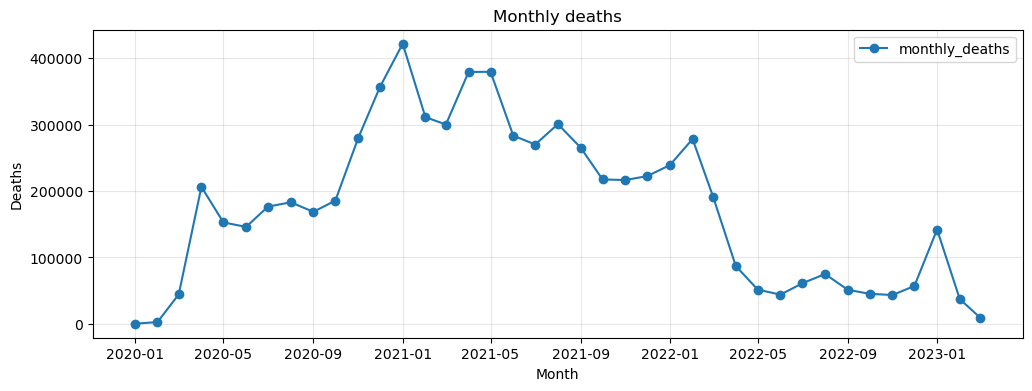

In [9]:
ax = mart_df.plot(
    x="month_start_date",
    y="monthly_deaths",
    figsize=(12, 4),
    marker="o",
    title="Monthly deaths",
)
ax.set_xlabel("Month")
ax.set_ylabel("Deaths")
plt.grid(True, alpha=0.3)
plt.show()

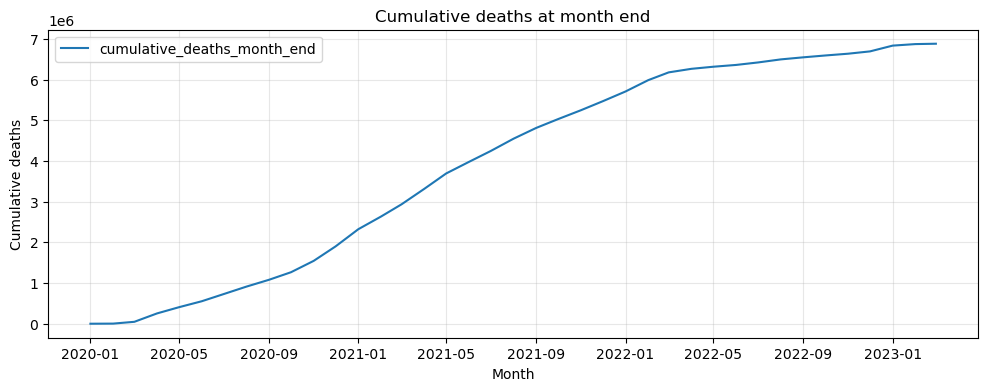

In [10]:
ax = mart_df.plot(
    x="month_start_date",
    y="cumulative_deaths_month_end",
    figsize=(12, 4),
    title="Cumulative deaths at month end",
)
ax.set_xlabel("Month")
ax.set_ylabel("Cumulative deaths")
plt.grid(True, alpha=0.3)
plt.show()

## 8. Топ месяцев по смертности

In [11]:
top_months_df = read_sql("""
select
    report_year,
    report_month,
    monthly_deaths,
    cumulative_deaths_month_end
from mart.covid_deaths_monthly
order by monthly_deaths desc
limit 10;
""")


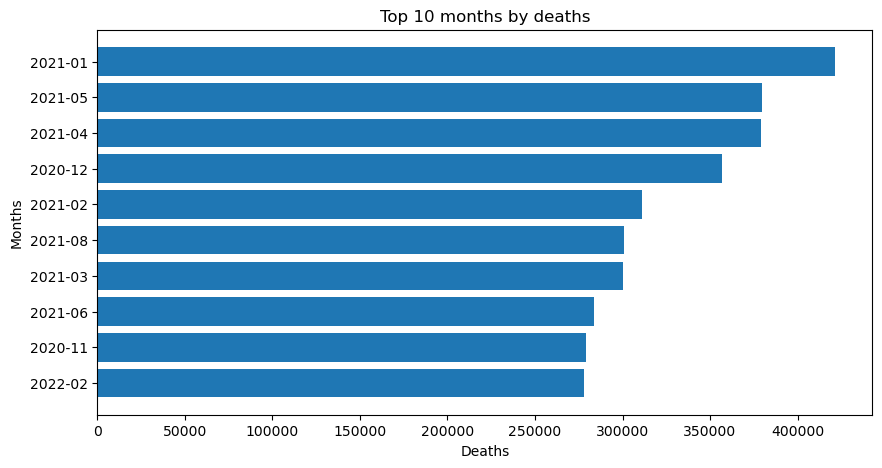

In [12]:
top_months_plot_df = top_months_df.copy()
top_months_plot_df["year_month"] = (
    top_months_plot_df["report_year"].astype(str)
    + "-"
    + top_months_plot_df["report_month"].astype(str).str.zfill(2)
)

plot_df = top_months_plot_df.sort_values("monthly_deaths")
fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(plot_df["year_month"], plot_df["monthly_deaths"])
ax.set_title("Top 10 months by deaths")
ax.set_xlabel("Deaths")
ax.set_ylabel("Months")

plt.show()

In [13]:
engine.dispose()